In [1]:
import pandas as pd
import autoslo.utils.paths as pu
from  autoslo.workload_execution.trace import Trace

df = pu.RunLocator.get_runs_df()
df

,run_id,workload_name,num_queries,scale_factor,schema_name,blueprint_name,query_router_name,maxconns,closed_loop
0,1763237926,benchmarking_workload_1_1_5,5,1000,ext_tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False
1,1763238067,benchmarking_workload_1_1_5,5,1000,ext_tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False
2,1763238802,benchmarking_workload_1_1_5,5,1000,ext_tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False
3,1763238866,benchmarking_workload_1_1_5,5,1000,ext_tpcds1000,single_16,RFixed(fixed_cluster_name='cluster_16'),1000,False
4,1763238930,benchmarking_workload_1_1_5,5,1000,ext_tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False
...,...,...,...,...,...,...,...,...,...
95,1765379858,tpcds_99templates_10pctheavy_30meaninterarrivals,125,1000,tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False
96,1765385044,tpcds_99templates_10pctheavy_10meaninterarrivals,349,1000,tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False
97,1765395457,tpcds_99templates_25pctheavy_120meaninterarrivals,34,1000,tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False
98,1765400000,tpcds_99templates_25pctheavy_60meaninterarrivals,63,1000,tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False


In [2]:
pct_heavy_options = [0, 10, 25, 50]
mean_interarrival_options = [10, 30, 60, 120]
rpus = [4, 8, 16, 32]

records = []

for pct_heavy in pct_heavy_options:
    for mean_interarrival in mean_interarrival_options:
        for rpu in rpus:
            run_ids = pu.RunLocator.get_run_ids(
                schema_name='ext_tpcds1000',
                workload_name="{}pctheavy_{}meaninterarrival".format(
                    pct_heavy, mean_interarrival
                ),
                blueprint_name=f"single_{rpu}",
            )

            records.append(
                {
                    "pct_heavy": pct_heavy,
                    "mean_interarrival": mean_interarrival,
                    "rpu": rpu,
                    "blueprint_name": f"single_{rpu}",
                    "last_run_id": max(run_ids) if len(run_ids) > 0 else None,
                }
            )
results_df = pd.DataFrame(records)
results_df

,pct_heavy,mean_interarrival,rpu,blueprint_name,last_run_id
0,0,10,4,single_4,1763346358
1,0,10,8,single_8,1763315325
2,0,10,16,single_16,1763304261
3,0,10,32,single_32,1763978737
4,0,30,4,single_4,1763336464
...,...,...,...,...,...
59,50,60,32,single_32,1763970399
60,50,120,4,single_4,1763323616
61,50,120,8,single_8,1763299918
62,50,120,16,single_16,1763291740


In [7]:
# For each row in results_df, compute the p90, p95 and p99 latency using the trace
p50_series = []
p90_series = []
p95_series = []
p99_series = []
total_runtime_series = []

for idx, row in results_df.iterrows():
    run_id = row['last_run_id']


    trace = Trace(run_id)
    latencies_s = pd.Series(trace.latencies_s)
    p50_series.append(latencies_s.quantile(0.5))
    p90_series.append(latencies_s.quantile(0.9))
    p95_series.append(latencies_s.quantile(0.95))
    p99_series.append(latencies_s.quantile(0.99))
    total_runtime_series.append(latencies_s.sum())

results_df['p50_latency_s'] = p50_series
results_df['p90_latency_s'] = p90_series
results_df['p95_latency_s'] = p95_series
results_df['p99_latency_s'] = p99_series
results_df['total_runtime_s'] = total_runtime_series

In [4]:
# Select the best model and initialize it
import autoslo.utils.paths as pu
import xgboost as xgb
import os
from autoslo.featurization.featurizer import Featurizer

import numpy as np
from tqdm.auto import tqdm

models_df = pu.ModelLocator.get_runs_df()

models_df = models_df[
    (models_df["model_params__objective_params__objective"] != 'reg:quantileerror')
    # (models_df["featurization_params__label_summary_metric"] == "p99")
    # & (models_df["featurization_params__label_summary_metric"] == "p99")
    # & (models_df["featurization_params__use_num_queries"] == False)
    # & (models_df["model_params__monotonic_rpu"] == True)
]


selected_run_dict = (
    models_df.sort_values(by="test_MALE", ascending=False)
    .iloc[0]
    .to_dict()
)

print("Selected model run ID:", selected_run_dict["run_id"])

model = xgb.XGBRegressor()
model_dir = os.path.join(pu.get_models_dir(), selected_run_dict["run_id"])
model_path = os.path.join(model_dir, "model.json")
model.load_model(model_path)

featurization_params = {
    k.replace("featurization_params__", ""): v
    for k, v in selected_run_dict.items()
    if k.startswith("featurization_params__")
}

featurizer = Featurizer.from_name(
    featurization_params["featurizer_name"], **featurization_params
)

label_name = featurizer.label_name
nolog_label_name = label_name.replace("log1p_", "")
was_logged = label_name.startswith("log1p_")

results_df[f"{nolog_label_name}_predicted"] = None

for idx, row in tqdm(results_df.iterrows(), total=len(results_df)):
    run_id = row["last_run_id"]
    trace = Trace(run_id)
    features, label = featurizer.featurize_trace(trace)

    predicted = model.predict(np.array(features).reshape(1, -1))

    results_df.at[idx, f"{nolog_label_name}_predicted"] = (
        np.expm1(predicted) if was_logged else predicted
    )


results_df.head()

Selected model run ID: 1765294896_1913


  0%|          | 0/64 [00:00<?, ?it/s]

,pct_heavy,mean_interarrival,rpu,blueprint_name,last_run_id,p90_latency_s,p95_latency_s,p99_latency_s,total_runtime_s,latency_s_p99_predicted
0,0,10,4,single_4,1763346358,3600.004227,3600.008419,3600.013368,711258.048603,2911.1484
1,0,10,8,single_8,1763315325,2968.374126,3575.498656,3600.011258,348740.852309,3579.9417
2,0,10,16,single_16,1763304261,1649.976529,1870.926920,2223.270434,155784.829464,802.0611
3,0,10,32,single_32,1763978737,105.227352,157.603584,299.927598,13476.913319,80.415306
4,0,30,4,single_4,1763336464,3600.006985,3600.010294,3600.014189,240952.976271,2510.024


In [32]:
features

[66.47428748,
 209748.95442799985,
 17.0,
 40.39999999999998,
 15.999999999999972,
 32.0]

In [33]:
selected_run_dict

{'run_id': '1765294896_1913',
 'model_params__random_seed': 42,
 'model_params__model_type': 'xgboost',
 'model_params__num_boost_rounds': 200,
 'model_params__max_depth': 15,
 'model_params__monotonic_rpu': True,
 'model_params__objective_params__objective_type': 'custom',
 'model_params__objective_params__objective': 'asymmetric_mse',
 'model_params__objective_params__heavy_side': 10.0,
 'model_params__objective_params__light_side': 0.5,
 'model_params__objective_params__low_threshold': nan,
 'model_params__objective_params__low_value_weight': nan,
 'data_params__dataset': 'redset',
 'data_params__bin_granularity': 'hourly',
 'data_params__train_split_name': 'train',
 'data_params__validation_split_name': 'validation',
 'data_params__test_split_name': 'test',
 'featurization_params__featurizer_name': 'FMinimal',
 'featurization_params__label_in_log_space': True,
 'featurization_params__label_summary_metric': 'p99',
 'featurization_params__use_num_queries': False,
 'featurization_para

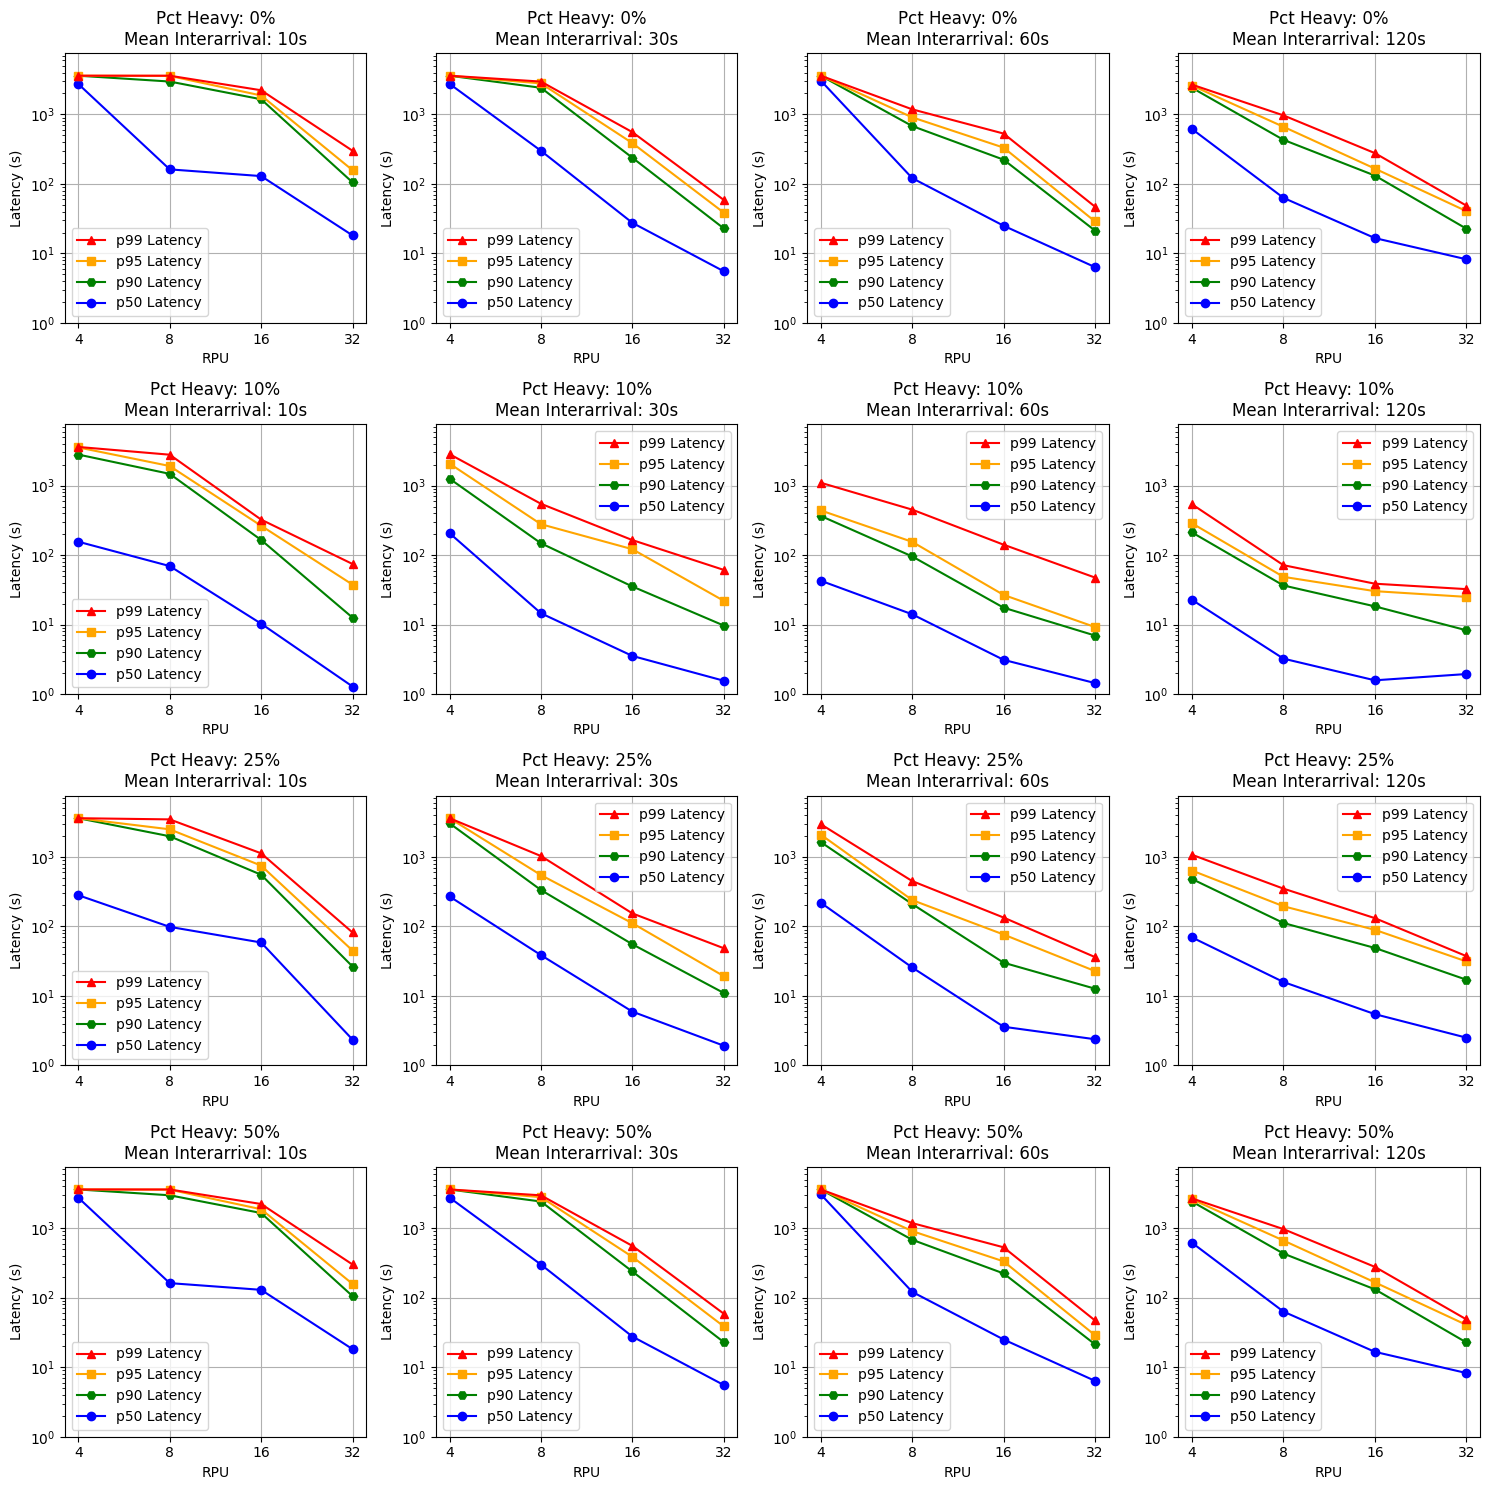

In [ ]:
# Create a 4x4 grid of plots, where each row corresponds to a pct_heavy value and each column corresponds to a mean_interarrival value.
# In each plot, have the x axis be rpu (in a logarithmic base 2 scale) and the
# y axis be latency. Plot p90, p95 and p99 latencies as separate lines in each plot,
# with appropriate markers, labels and legends.
# Enforce the same x and y axis limits across all plots for easy comparison,
# but don't actually share the axes - we want to see the tick labels in each plot.

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(
    nrows=4, ncols=4, figsize=(15, 15), sharex=False, sharey=False
)

ymax = (
    results_df[
        [
            "p90_latency_s",
            "p95_latency_s",
            "p99_latency_s",
            nolog_label_name + "_predicted",
        ]
    ]
    .max()
    .max()
    * 2
)


for i, pct_heavy in enumerate(pct_heavy_options):
    for j, mean_interarrival in enumerate(mean_interarrival_options):
        ax = axes[i, j]
        subset = results_df[
            (results_df["pct_heavy"] == pct_heavy)
            & (results_df["mean_interarrival"] == mean_interarrival)
        ]
        ax.plot(
            subset["rpu"],
            subset["p50_latency_s"],
            marker="o",
            label="p50 Latency",
            color='blue'
        )
        ax.plot(
            subset["rpu"],
            subset["p90_latency_s"],
            marker="H",
            label="p90 Latency",
            color='green'
        )
        ax.plot(
            subset["rpu"],
            subset["p95_latency_s"],
            marker="s",
            label="p95 Latency",
            color='orange'
        )
        ax.plot(
            subset["rpu"],
            subset["p99_latency_s"],
            marker="^",
            label="p99 Latency",
            color='red'
        )
        # ax.plot(
        #     subset["rpu"],
        #     subset[nolog_label_name + "_predicted"],
        #     marker="x",
        #     label="Predicted",
        #     linestyle="--",
        #     color='red'
        # )
       

        ax.set_xscale("log", base=2)
        ax.set_title(
            f"Pct Heavy: {pct_heavy}%\nMean Interarrival: {mean_interarrival}s"
        )
        ax.set_xlabel("RPU")
        ax.set_ylabel("Latency (s)")
        ax.set_ylim(1, ymax)
        ax.set_yscale("log")

        # Display x ticks without scientific notation
        ax.set_xticks(subset["rpu"])
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

        # Invert the order of legend elements
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[::-1], labels[::-1])
        ax.grid(True)

plt.tight_layout()
#plt.savefig("chunk_tail_latency_plots.png", dpi=300)
plt.show()

In [30]:
import numpy as np

y_true = 10
y_pred= 20

float(np.mean(np.abs(np.log1p(y_true) - np.log1p(y_pred))))


0.6466271649250523

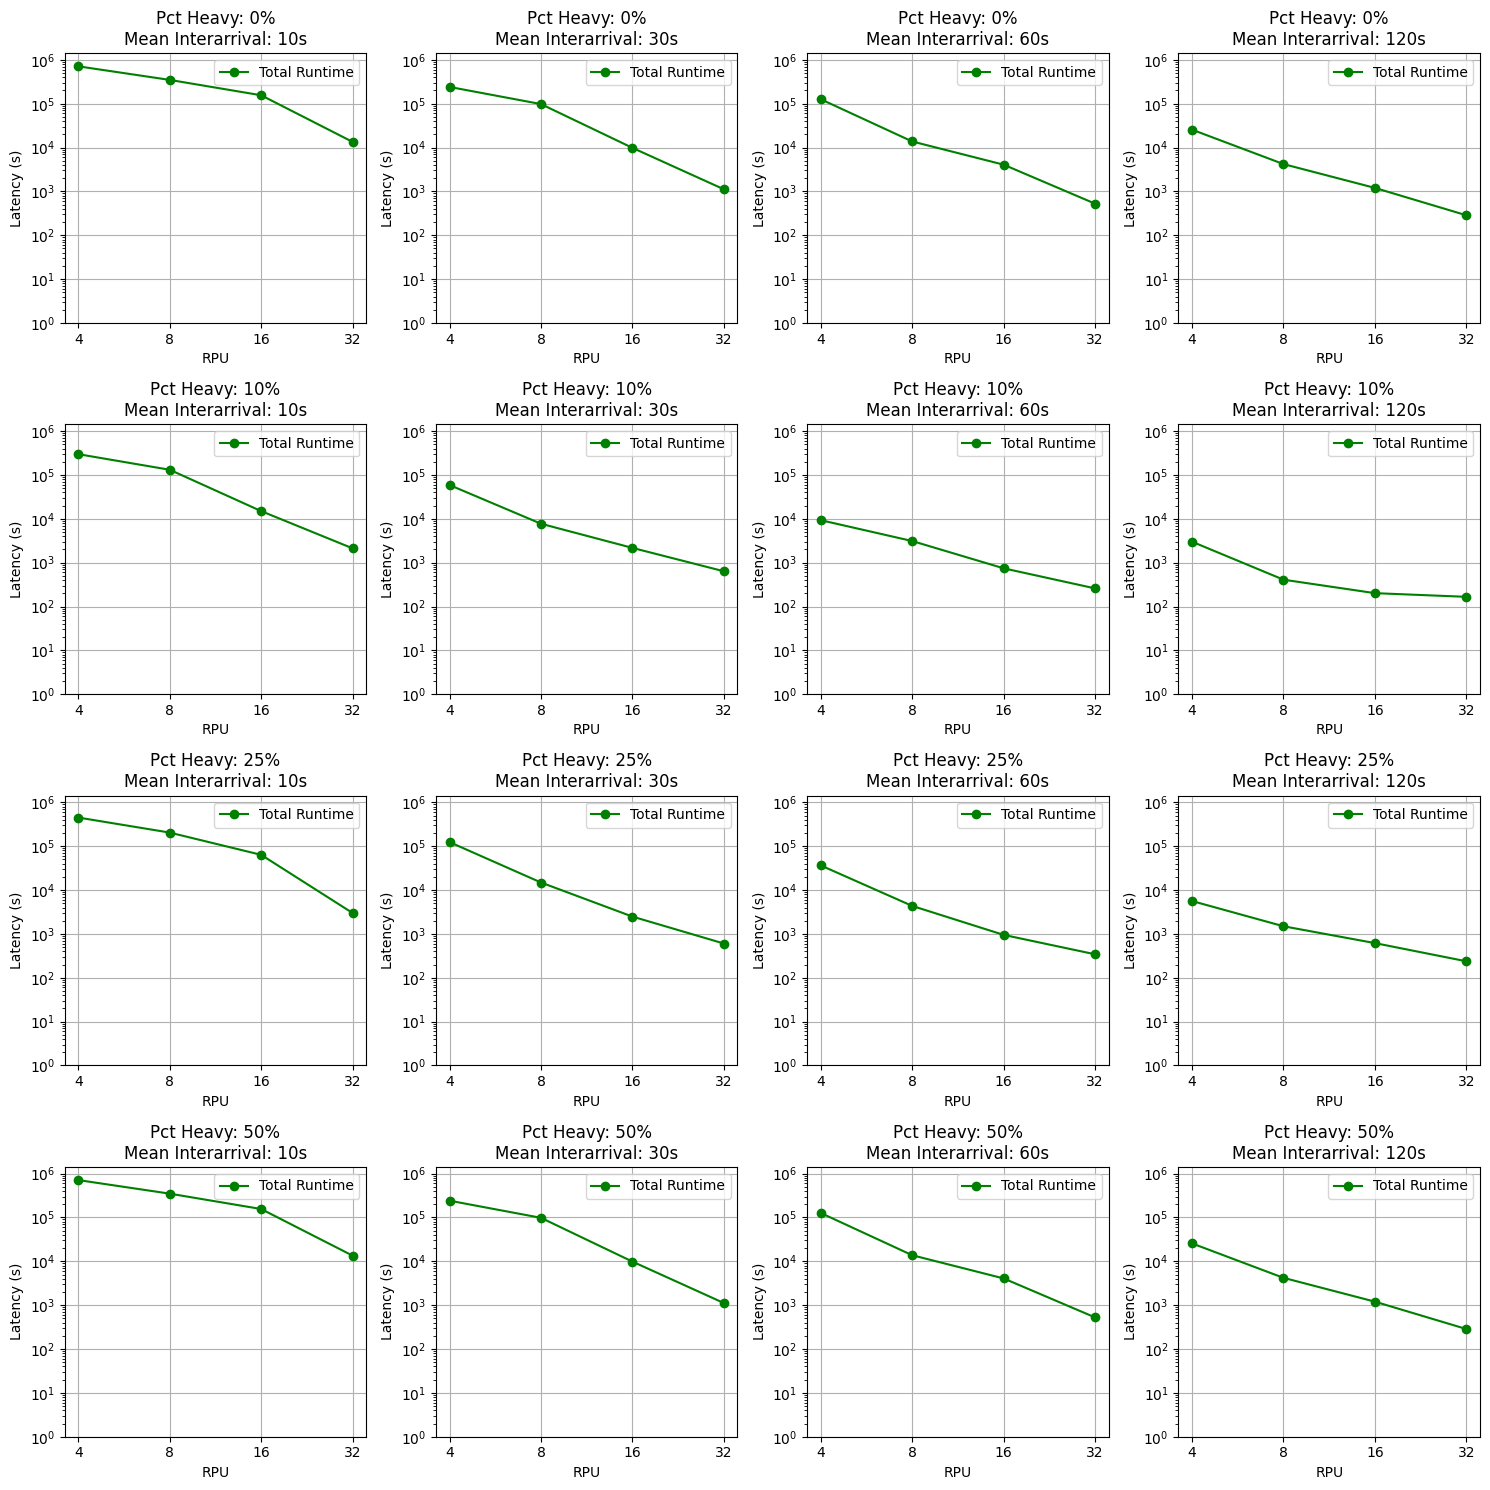

In [28]:
# Create a 4x4 grid of plots, where each row corresponds to a pct_heavy value and each column corresponds to a mean_interarrival value.
# In each plot, have the x axis be rpu (in a logarithmic base 2 scale) and the
# y axis be latency. Plot p90, p95 and p99 latencies as separate lines in each plot,
# with appropriate markers, labels and legends.
# Enforce the same x and y axis limits across all plots for easy comparison,
# but don't actually share the axes - we want to see the tick labels in each plot.

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(
    nrows=4, ncols=4, figsize=(15, 15), sharex=False, sharey=False
)

ymax = (
    results_df[
        [
            "total_runtime_s",
        ]
    ]
    .max()
    .max()
    * 2
)


for i, pct_heavy in enumerate(pct_heavy_options):
    for j, mean_interarrival in enumerate(mean_interarrival_options):
        ax = axes[i, j]
        subset = results_df[
            (results_df["pct_heavy"] == pct_heavy)
            & (results_df["mean_interarrival"] == mean_interarrival)
        ]
        ax.plot(
            subset["rpu"],
            subset["total_runtime_s"],
            marker="o",
            label="Total Runtime",
            color='green'
        )
       

        ax.set_xscale("log", base=2)
        ax.set_title(
            f"Pct Heavy: {pct_heavy}%\nMean Interarrival: {mean_interarrival}s"
        )
        ax.set_xlabel("RPU")
        ax.set_ylabel("Latency (s)")
        ax.set_ylim(1, ymax)
        ax.set_yscale("log")

        # Display x ticks without scientific notation
        ax.set_xticks(subset["rpu"])
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

        ax.legend()
        ax.grid(True)

plt.tight_layout()
plt.show()

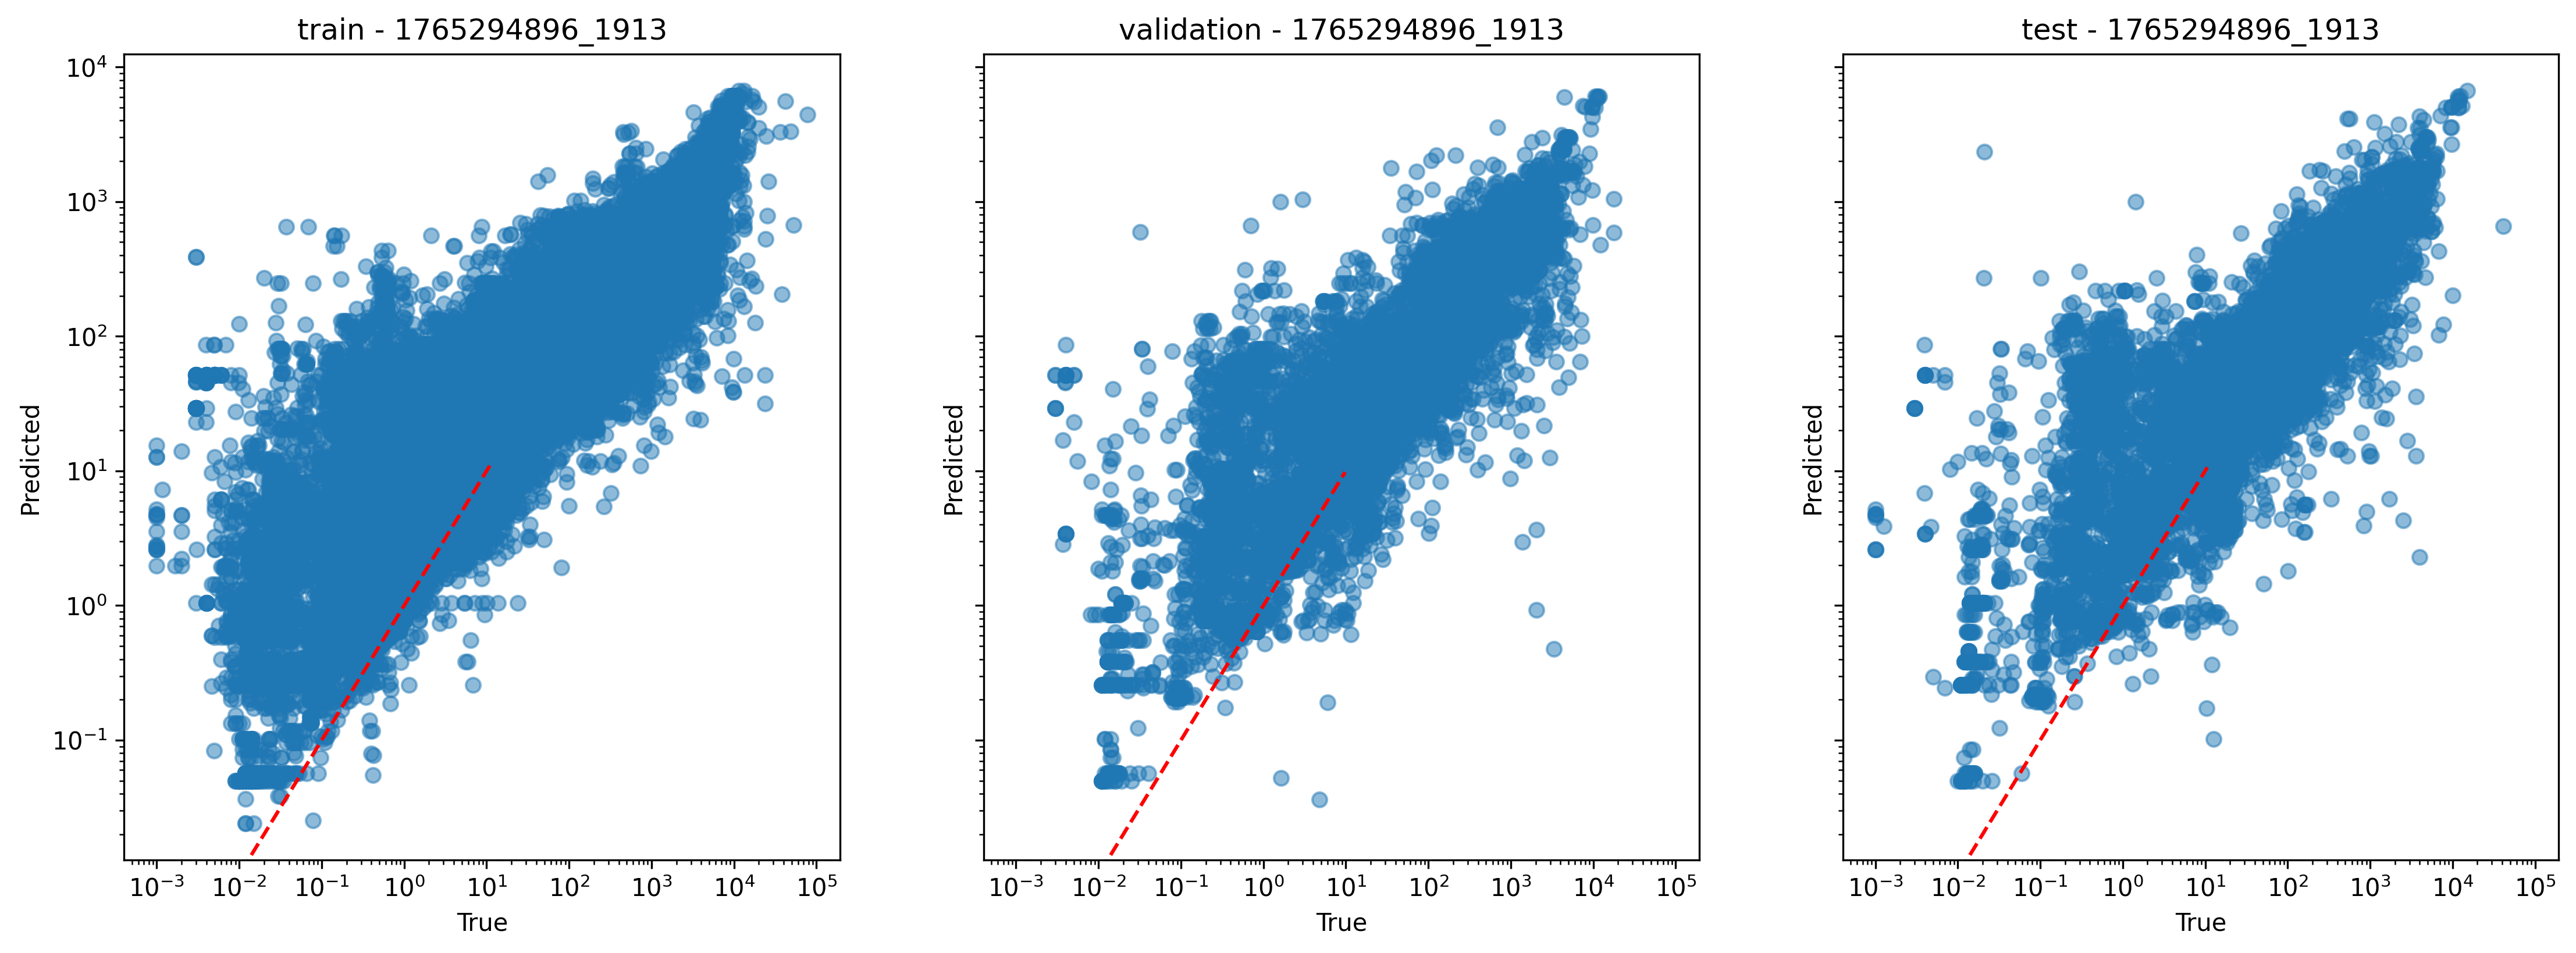

In [29]:
from IPython.display import display, Image

path = f'//home/markakis/chunkbench/data/models/{selected_run_dict["run_id"]}/scatter.png'
display(Image(filename=path))